# Telco churn: data audit and exploratory analysis

This notebook reads the repository CSV, verifies the blank-charge invariant, applies the shared cleaning function, and displays reproducible EDA figures. It does not train the deployed model; run `02_train_evaluate.ipynb` for that.

The current file contains 7,043 records and 21 columns. The 11 whitespace-only `TotalCharges` entries are only converted to zero after verifying tenure is zero.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'backend'))

from train_model import load_and_clean_data, save_eda_figures

DATA_PATH = PROJECT_ROOT / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'telco_clean.csv'
FIGURES_PATH = PROJECT_ROOT / 'reports' / 'figures'
print(f'Dataset: {DATA_PATH}')

Dataset: d:\churnxai\data\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
raw = pd.read_csv(DATA_PATH)
blank_charge = raw['TotalCharges'].astype('string').str.strip().eq('').fillna(False)
audit_preview = {
    'rows': len(raw),
    'columns': len(raw.columns),
    'parsed_null_cells': int(raw.isna().sum().sum()),
    'whitespace_only_TotalCharges': int(blank_charge.sum()),
    'blank_charge_tenure_values': raw.loc[blank_charge, 'tenure'].value_counts().to_dict(),
    'churn_counts': raw['Churn'].value_counts().to_dict(),
}
display(audit_preview)
assert raw.loc[blank_charge, 'tenure'].eq(0).all(), 'Review blank charge records before imputing.'

{'rows': 7043,
 'columns': 21,
 'parsed_null_cells': 0,
 'whitespace_only_TotalCharges': 11,
 'blank_charge_tenure_values': {0: 11},
 'churn_counts': {'No': 5174, 'Yes': 1869}}

In [3]:
cleaned, audit = load_and_clean_data(DATA_PATH)
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
cleaned.to_csv(PROCESSED_PATH, index=False)
display(audit)
display(cleaned.head())
print(f'Cleaned data saved to {PROCESSED_PATH}')

{'source_file': 'D:\\churnxai\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv',
 'rows': 7043,
 'columns': 21,
 'parsed_null_cells_before_cleaning': 0,
 'whitespace_total_charges': 11,
 'blank_charge_rows_with_zero_tenure': 11,
 'churn_counts': {'No': 5174, 'Yes': 1869}}

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Churn
0,1,29.85,29.85,Month-to-month,DSL,Electronic check,Female,No,Yes,No,No,No phone service,No,Yes,No,No,No,No,Yes,0
1,34,56.95,1889.5,One year,DSL,Mailed check,Male,No,No,No,Yes,No,Yes,No,Yes,No,No,No,No,0
2,2,53.85,108.15,Month-to-month,DSL,Mailed check,Male,No,No,No,Yes,No,Yes,Yes,No,No,No,No,Yes,1
3,45,42.30,1840.75,One year,DSL,Bank transfer (automatic),Male,No,No,No,No,No phone service,Yes,No,Yes,Yes,No,No,No,0
4,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check,Female,No,No,No,Yes,No,No,No,No,No,No,No,Yes,1


Cleaned data saved to d:\churnxai\data\processed\telco_clean.csv


## Churn rate and feature relevance



The Wilson score interval estimates uncertainty around the observed churn proportion. Categorical predictors are screened with Pearson chi-square tests and Cramer's V effect sizes; numeric predictors use point-biserial correlation and Cohen's d (churn minus no churn). Percentile bootstrap intervals summarize uncertainty in effect sizes. Holm controls family-wise error, while Benjamini-Hochberg (BH) controls the false discovery rate across the 19 tests.



`drop_candidate` marks a feature whose Holm-adjusted p-value is at least 0.05. It is a screening flag for review, not an instruction to remove a feature automatically. These univariate associations are not causal effects.

In [5]:
from train_model import CATEGORICAL_FEATURES, NUMERIC_FEATURES

from statistical_analysis import feature_relevance_tests, wilson_interval



churned_customers = int(cleaned['Churn'].sum())

customer_count = len(cleaned)

churn_rate = churned_customers / customer_count

churn_ci_low, churn_ci_high = wilson_interval(churned_customers, customer_count)

print(f'Churn rate: {churn_rate:.2%}')

print(f'Wilson 95% CI: [{churn_ci_low:.2%}, {churn_ci_high:.2%}]')



feature_relevance = feature_relevance_tests(

    cleaned,

    categorical_features=CATEGORICAL_FEATURES,

    numeric_features=NUMERIC_FEATURES,

    target_column='Churn',

    bootstrap_resamples=2000,

    seed=42,

    alpha=0.05,

)

FEATURE_RELEVANCE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'feature_relevance.csv'

feature_relevance.to_csv(FEATURE_RELEVANCE_PATH, index=False)

display(feature_relevance)

print(f'Feature relevance saved to {FEATURE_RELEVANCE_PATH}')

print('Drop candidates for review (Holm-adjusted p >= 0.05):', feature_relevance.loc[feature_relevance['drop_candidate'], 'feature'].tolist())

print('Minimum expected cell count by chi-square test:')

display(feature_relevance.loc[feature_relevance['feature_type'] == 'categorical', ['feature', 'minimum_expected_count']])

Churn rate: 26.54%
Wilson 95% CI: [25.52%, 27.58%]


,feature,feature_type,test,statistic,degrees_freedom,p_value,effect_size_name,effect_size,effect_ci_low,effect_ci_high,minimum_expected_count,p_holm,p_bh,drop_candidate,significant_holm
0,Contract,categorical,Pearson chi-square,1184.596572,2,5.863038e-258,Cramer's V,0.410116,0.392075,0.428084,390.889820,1.113977e-256,1.113977e-256,False,True
1,tenure,numeric,Point-biserial correlation,-0.352229,7041,7.999058e-205,Cohen's d (churn - no churn),-0.852250,-0.903755,-0.801016,NaN,1.439830e-203,7.599105e-204,False,True
2,OnlineSecurity,categorical,Pearson chi-square,849.998968,2,2.661150e-185,Cramer's V,0.347400,0.326649,0.366977,404.954423,4.523954e-184,1.685395e-184,False,True
3,TechSupport,categorical,Pearson chi-square,828.197068,2,1.443084e-180,Cramer's V,0.342916,0.321993,0.363558,404.954423,2.308934e-179,6.854649e-180,False,True
4,InternetService,categorical,Pearson chi-square,732.309590,2,9.571788e-160,Cramer's V,0.322455,0.301696,0.342477,404.954423,1.435768e-158,3.637280e-159,False,True
5,PaymentMethod,categorical,Pearson chi-square,648.142327,3,3.682355e-140,Cramer's V,0.303359,0.280587,0.326931,403.892943,5.155297e-139,1.166079e-139,False,True
6,OnlineBackup,categorical,Pearson chi-square,601.812790,2,2.079759e-131,Cramer's V,0.292316,0.272716,0.312389,404.954423,2.703687e-130,5.645061e-131,False,True
7,DeviceProtection,categorical,Pearson chi-square,558.419369,2,5.505219e-122,Cramer's V,0.281580,0.261309,0.301856,404.954423,6.606263e-121,1.307490e-121,False,True
8,StreamingMovies,categorical,Pearson chi-square,375.661479,2,2.667757e-82,Cramer's V,0.230951,0.214966,0.247072,404.954423,2.934532e-81,5.631931e-82,False,True
9,StreamingTV,categorical,Pearson chi-square,374.203943,2,5.528994e-82,Cramer's V,0.230502,0.214831,0.246580,404.954423,5.528994e-81,1.050509e-81,False,True


Feature relevance saved to d:\churnxai\data\processed\feature_relevance.csv
Drop candidates for review (Holm-adjusted p >= 0.05): ['PhoneService', 'gender']
Minimum expected cell count by chi-square test:


,feature,minimum_expected_count
0,Contract,390.889820
2,OnlineSecurity,404.954423
3,TechSupport,404.954423
4,InternetService,404.954423
5,PaymentMethod,403.892943
6,OnlineBackup,404.954423
7,DeviceProtection,404.954423
8,StreamingMovies,404.954423
9,StreamingTV,404.954423
12,PaperlessBilling,762.142269


reports\figures\churn_distribution.png


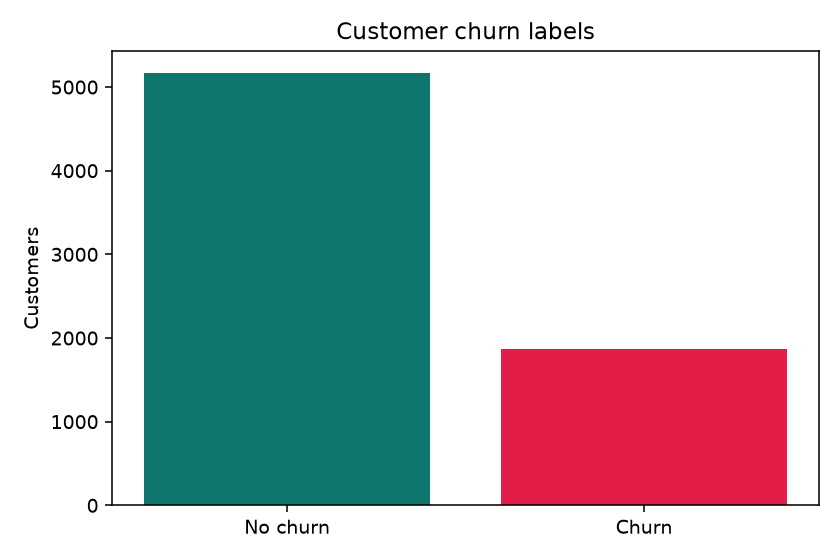

reports\figures\churn_by_contract.png


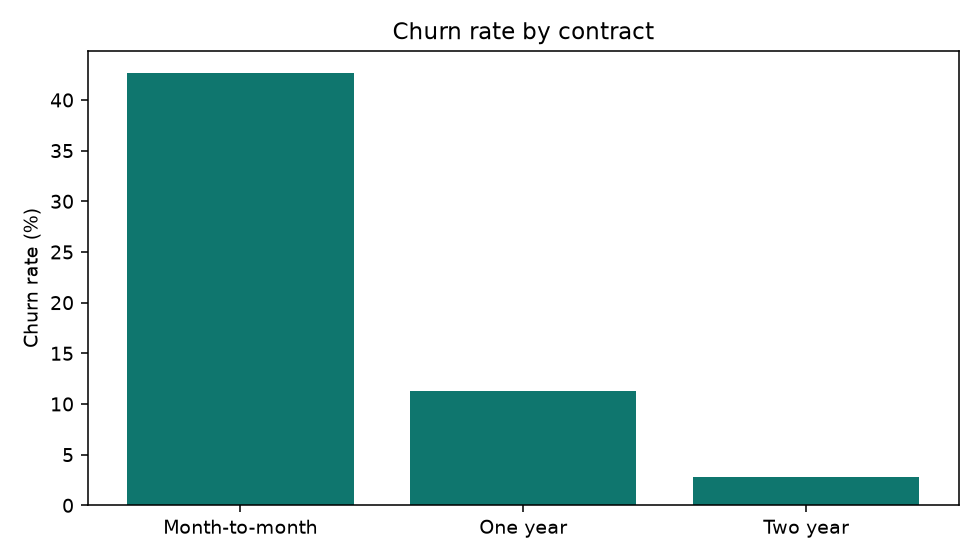

reports\figures\tenure_by_churn.png


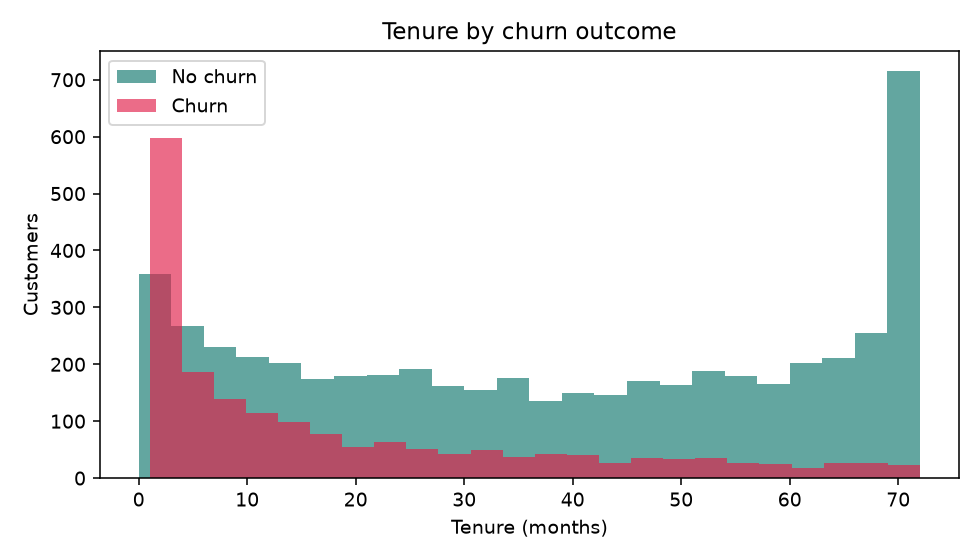

reports\figures\monthly_charges_by_churn.png


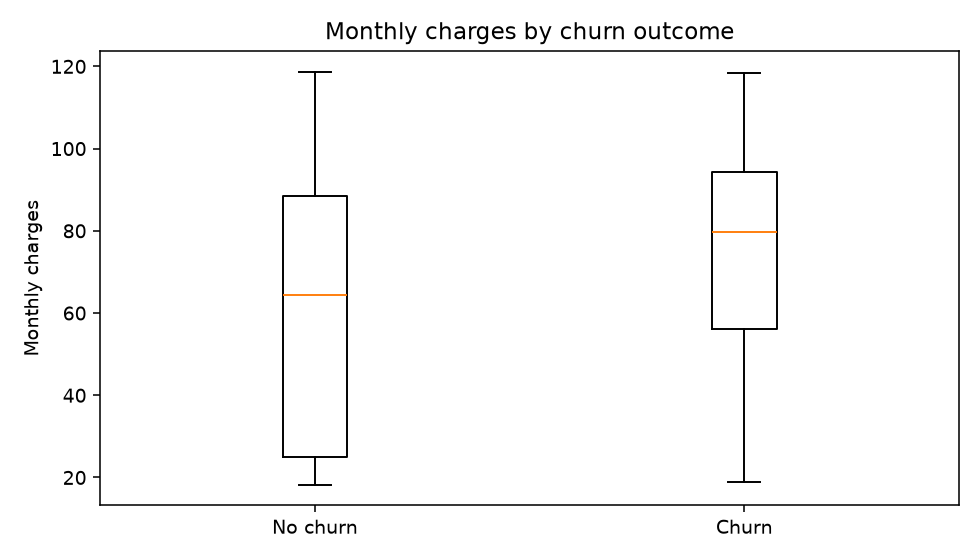

In [6]:
figure_paths = save_eda_figures(cleaned, FIGURES_PATH)
for figure_path in figure_paths:
    print(figure_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(figure_path)))